# World Model from Scratch

In [1]:
import torch
from torch import nn
import torch.nn.functional as F

In [2]:
# Select GPU
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(device)

mps


### (V) Vision Model 

It compresses information, i.e. it *encodes the high dimensional observation* \[ the input \] *into a low dimensional latent vector*. The paper uses a **Variational AutoEncoder** for this purpose.

Takes the original input.


### Variational AutoEncoder

Takes a vector as input, which is passed through two separate CNNs. The first one gives $\mu$ (the center/mean of the distribution), while the second one gives $\sigma$ (the spread of the distribution). Thus, the two CNNs point to an area in a latent vector space, which theoretically contains abstract representations of concepts.

The fact that it is an area instead of a concrete point gives the VAE the ability to generate novel images, that have not been encountered during training.

Using $\mu$ and $\sigma$, we compute $z = \mu + \sigma * \epsilon$, where $\epsilon$ is random noise drawn from $N(0, 1)$, which is a fixed distribution outside of the model. Thus, the randomness is in $\epsilon$, which is a constant, allowing us to backpropagate.

In practice, we do:

```python
mu = hidden @ W_mu + b_mu
log_sigma = hidden @ W_sigma + b_sigma
sigma = exp(log_sigma)
```

So that sigma is always positive. 

Then, the decoder is a mirror of the encoder. 

In [3]:
class VariationalAutoEncoder(nn.Module):
    def __init__(self, d_latent):
        super().__init__()
        self.d_latent = d_latent
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1),
            nn.ReLU()
        )
        self.fc_mu = nn.Linear(4096, d_latent)
        self.fc_log_sigma = nn.Linear(4096, d_latent)
        self.fc_decoder = nn.Linear(d_latent, 4096)
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(32, 3, kernel_size=4, stride=2, padding=1),
            #sigmoid corresponds to normalized pixel values
            nn.Sigmoid()
        )

    def forward(self, x):
        # [batch_size, 3, 64, 64] => [batch_size, 256,  4,  4]
        enc = self.encoder(x)
    
        # [batch_size, 256,  4,  4] => [batch_size, 4096]
        enc = enc.flatten(start_dim=1) 

        # [batch_size, 4096] => [batch_size, d_latent]
        mu = self.fc_mu(enc)

        # [batch_size, 4096] => [batch_size, d_latent]
        log_sigma = self.fc_log_sigma(enc)
        sigma = torch.exp(log_sigma)

        # sample epsilon from N(0, 1)
        epsilon = torch.randn_like(sigma)
        
        z = mu + sigma * epsilon

        # [batch_size, d_latent] -> [batch_size, 4096]
        dec_in = self.fc_decoder(z)

        # [batch_size, 4096] -> [batch_size, 256, 4, 4]
        dec_in = dec_in.reshape(-1, 256, 4, 4) 

        # [batch_size, 256, 4, 4] -> [batch_size, 3, 64, 64]]
        reconstruction = self.decoder(dec_in)

        return reconstruction, mu, log_sigma, z

For loss, we use MSE alongside KL divergence, which computes the difference between the two Gaussian distributions, $N(\mu, \sigma)$ and $N(0,1)$, the distribution we sample $\epsilon$ from. We do this because we want the latent space to resemble $N(0,1)$, so that the latent space is smooth and continuous (if there are discontinuities in it, then the decoder will have blind spots).

$$\text{Loss} = ||\text{input} - \text{reconstruction}||² + KL(N(\mu, \sigma) || N(0,1))$$

The KL formula is self-correcting:
- μ drifts from 0 → KL penalizes it
- σ drifts from 1 → KL penalizes it

$$KL = -0.5 * \sum(1 + log(\sigma^2) - \mu^2 - \sigma^2)$$

In [4]:
def vae_loss(input, reconstruction, mu, log_sigma):
    log_sigma = torch.clamp(log_sigma, -4, 4)
    mse = F.mse_loss(input, reconstruction, reduction='sum') / input.shape[0]
    mu = torch.clamp(mu, -10, 10)
    kl = 0.5 * torch.sum(1 + 2 * log_sigma - mu**2 - torch.exp(2*log_sigma)) / input.shape[0]
    
    return mse, kl

### (M) Memory RNN
Uses past states (*historical codes to create a representation*) to predict future states. Takes **(V)**'s output as input.

While **(V)** sees and compresses what the agent sees, **(M)** adds a time dimension, so to speak. Its purpose is to predict future $z$ vectors that **(V)** will produce. 

*Since many complex environments are stochastic in nature, we train our RNN to output a probability density function p(z) instead of a deterministic prediction of z.*

Stochastic environment means unexpected things can happen, so the model needs something that allows more wiggle room, i.e. a probability distribution. A simple Gaussian distribution doesn't cut it, because, for instance, say there are two monsters, each with an equal chance of shooting the agent (who needs to dodge). Then, the model wouldn't know where to center the gaussian, it would need two "humps". We thus need a multinomial distribution.

The **(M)** model needs to output the parameters of this mix of Gaussian distributions:
1. Mean
2. Variance
3. Weight (i.e. how probable is this particular Gaussian compared to the others; all weights must sum to 1)
All for each dimension of $z$.

The RNN will model $P(z_{t+1} | a_t, z_t, h_t)$, where $a_t$ is the just taken action and $h_t$ embeds the history (what happened before). Note that $h_t$ is embedded in the RNN's architecture, it's not an explicit parameter; the RNN takes as input a concatenation of $a_t$ and $z_t$.

Then, the hidden state of the RNN $h_t$ is fed into the MDN (Mixture Density Network), which, in turn, produces the aforementioned multinomial distribution.

MDN is just a single linear layer that takes $h_t$ as input and outputs a $[\mu + \sigma + \pi]$:
- $\mu: \text{num\_gaussians} \times \text{d\_latent}$
- $\sigma: \text{num\_gaussians} \times \text{d\_latent}$
- $\pi: \text{num\_gaussians}$

Then:
- reshape and split that output into $\mu$, $\sigma$, and $\pi$.
- apply exp to $\log{\sigma}$ to get $\sigma > 0$ 
- apply softmax to $\pi$ to get weights that sum to 1
- $\mu$ has no activation, it can be any real number

In the end, to compute z, we do:
$$z = \mu + \tau * \sigma * \epsilon$$
Where $\tau$ is the temperature, i.e. a scalar which modifies the sampling region, so:
- Low $\tau$ (e.g. 0.1): $\sigma$ shrinks => samples cluster tightly around $\mu$ => more predictable environment
- High $\tau$ (e.g. 1.15): $\sigma$ grows → samples spread out → more random, chaotic environment


The flow is:
$$z_t, a_t \rightarrow RNN \rightarrow h_t \rightarrow \text{MDN head} \rightarrow (\pi, \mu, \sigma) → \text{sample} \ z_{t+1}$$

In [5]:
class Model(nn.Module):
    def __init__(self, d_latent, d_hidden, num_gaussians, num_actions):
        super().__init__()
        self.d_latent = d_latent
        self.d_hidden = d_hidden
        self.num_gaussians = num_gaussians
        self.num_actions = num_actions

        # |{Gas, Brake, Turn (L or R)}| + d_latent
        self.rnn = nn.LSTM(d_latent + num_actions, d_hidden, batch_first=True)
        self.fc_mdn = nn.Linear(d_hidden, 2 * num_gaussians * d_latent + num_gaussians)

    def forward(self, z_t, a_t, h):
        x = torch.cat([z_t, a_t], dim=-1)
        out, (h_t, c_t) = self.rnn(x, h)

        # [1, 256] -> [256]
        h_t = h_t.squeeze(0)
        c_t = c_t.squeeze(0)
        
        out = self.fc_mdn(out)
        log_sigma = torch.clamp(out[:, :, :self.num_gaussians * self.d_latent], min=-10, max=2)
        sigma = torch.exp(log_sigma)
        mu = out[:, :, self.num_gaussians * self.d_latent : 2 * self.num_gaussians * self.d_latent] 
        pi = out[:, :, 2 * self.num_gaussians * self.d_latent : ]
        pi = F.softmax(pi, dim=-1)

        return mu, sigma, pi, (h_t, c_t)

In [6]:
def mdn_loss(mu, sigma, pi, z_next, num_gaussians, d_latent):
    mu = mu.reshape(-1, num_gaussians, d_latent)
    sigma = sigma.reshape(-1, num_gaussians, d_latent)
    z_next = z_next.reshape(-1, d_latent).unsqueeze(1)

    dist = torch.distributions.Normal(mu, sigma)
    log_prob = dist.log_prob(z_next).sum(dim=-1)
    log_mix = torch.log(pi.reshape(-1, num_gaussians) + 1e-8) + log_prob

    return -torch.logsumexp(log_mix, dim=-1).mean()

### (C) Controller
**(C)** determines the correct course of action given $h_t$ and $z_t$. It is a simple linear layer that maps them to the vector of potential actions

In [7]:
class Controller(nn.Module):
    def __init__(self, d_hidden, d_latent, num_actions):
        super().__init__()
        self.W_c = nn.Linear(d_hidden + d_latent, num_actions)

    def forward(self, z_t, h_t):
        x = torch.cat([z_t, h_t], dim=-1)
        a_t = self.W_c(x)
        a_t = F.tanh(a_t)

        return a_t

### Putting it all together

In [8]:
import cv2
import numpy as np

def preprocess_frame(frame):
    frame = cv2.resize(frame, (64, 64))
    frame = frame.astype(np.float32) / 255.0
    frame = np.transpose(frame, (2, 0, 1))
    return frame

In [9]:
class WorldModel(nn.Module):
    def __init__(self, d_latent, d_hidden, num_gaussians, num_actions, temperature, environment):
        super().__init__()
        self.d_latent = d_latent
        self.d_hidden = d_hidden
        self.num_gaussians = num_gaussians
        self.num_actions = num_actions
        self.temperature = temperature
        self.environment = environment

        self.V = VariationalAutoEncoder(d_latent)
        self.M = Model(d_latent, d_hidden, num_gaussians, num_actions)
        self.C = Controller(d_hidden, d_latent, num_actions)

    def rollout(self):
        obs, _ = self.environment.reset()
        
        h = (torch.zeros(1, 1, self.d_hidden).to(device), 
             torch.zeros(1, 1, self.d_hidden).to(device))
             
        done = False
        cumulative_reward = 0

        while not done:
            frame = preprocess_frame(obs)
            
            obs_tensor = torch.FloatTensor(frame).unsqueeze(0).to(device)

            with torch.no_grad():
                reconstruction, mu_v, log_sigma_v, z = self.V(obs_tensor)
                
                a = self.C(z, h[0].squeeze(0))

                obs, reward, terminated, truncated, _ = self.environment.step(a.squeeze(0).cpu().numpy())
                done = terminated or truncated
                cumulative_reward += reward

                _, _, _, next_h = self.M(z.unsqueeze(1), a.unsqueeze(1), h)
                
                h = (next_h[0].unsqueeze(0), 
                     next_h[1].unsqueeze(0))

        return cumulative_reward

### Training a model using Gymnasium

In [10]:
import gymnasium as gym

env = gym.make("CarRacing-v3", render_mode="rgb_array")

objc[56332]: Class SDLApplication is implemented in both /Users/bogdanmunteanu/.conda/envs/world-model/lib/python3.11/site-packages/cv2/.dylibs/libSDL2-2.0.0.dylib (0x15f06c890) and /Users/bogdanmunteanu/.conda/envs/world-model/lib/python3.11/site-packages/pygame/.dylibs/libSDL2-2.0.0.dylib (0x1738e92c8). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.
objc[56332]: Class SDLAppDelegate is implemented in both /Users/bogdanmunteanu/.conda/envs/world-model/lib/python3.11/site-packages/cv2/.dylibs/libSDL2-2.0.0.dylib (0x15f06c8e0) and /Users/bogdanmunteanu/.conda/envs/world-model/lib/python3.11/site-packages/pygame/.dylibs/libSDL2-2.0.0.dylib (0x1738e9318). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.
objc[56332]: Class SDLTranslatorResponder is implemented in both /Users/bogdanmunteanu/.conda/envs/world-model/lib/python3.11/site-packages/cv2/.dylibs/libS

In [11]:
import os

os.makedirs("data", exist_ok=True)

def collect_rollouts(num_episodes=50):
    all_episodes = []
    all_frames = []
    for episode in range(num_episodes):
        frames = []
        actions = []
        obs, _ = env.reset()
        done = False
        while not done:
            action = env.action_space.sample()
            obs, reward, terminated, truncated, _ = env.step(action)
            frame = preprocess_frame(obs)
            frames.append(frame)
            actions.append(action)
            done = terminated or truncated
            all_frames.append(frame)
        all_episodes.append((frames, actions))
        print(f"Episode {episode} finished. Frames: {len(frames)}")
    
    data_to_save = np.empty(len(all_episodes), dtype=object)
    for i, episode in enumerate(all_episodes):
        data_to_save[i] = episode

    np.save("data/episodes.npy", data_to_save, allow_pickle=True)
    np.save("data/frames.npy", all_frames, allow_pickle=True)
    np.save("data/actions.npy", actions, allow_pickle=True)

collect_rollouts(num_episodes=50)

Episode 0 finished. Frames: 1000
Episode 1 finished. Frames: 1000
Episode 2 finished. Frames: 1000
Episode 3 finished. Frames: 1000
Episode 4 finished. Frames: 1000
Episode 5 finished. Frames: 1000
Episode 6 finished. Frames: 1000
Episode 7 finished. Frames: 1000
Episode 8 finished. Frames: 1000
Episode 9 finished. Frames: 1000
Episode 10 finished. Frames: 1000
Episode 11 finished. Frames: 1000
Episode 12 finished. Frames: 1000
Episode 13 finished. Frames: 1000
Episode 14 finished. Frames: 1000
Episode 15 finished. Frames: 1000
Episode 16 finished. Frames: 1000
Episode 17 finished. Frames: 1000
Episode 18 finished. Frames: 1000
Episode 19 finished. Frames: 1000
Episode 20 finished. Frames: 1000
Episode 21 finished. Frames: 1000
Episode 22 finished. Frames: 1000
Episode 23 finished. Frames: 1000
Episode 24 finished. Frames: 1000
Episode 25 finished. Frames: 1000
Episode 26 finished. Frames: 1000
Episode 27 finished. Frames: 1000
Episode 28 finished. Frames: 1000
Episode 29 finished. Fra

In [12]:
W = WorldModel(32, 256, 5, 3, 1, env)
W_d = W.to(device)

### Load frames for VAE training

In [13]:
from torch.utils.data import Dataset, DataLoader

class FrameDataset(Dataset):
    def __init__(self, frames):
        self.frames = frames
    
    def __len__(self):
        return len(self.frames)
    
    def __getitem__(self, idx):
        return torch.tensor(self.frames[idx])
    
    
frames = FrameDataset(np.load("data/frames.npy"))
frames_loader = DataLoader(frames, batch_size=32, shuffle=True)

### VAE Training

In [19]:
optimizer = torch.optim.Adam(W_d.V.parameters(), lr=1e-3)

def train_vae(vae, epochs=10, lr=1e-3, beta=0.1):
    vae.train()
    for epoch in range(epochs):
        for batch in frames_loader:
            batch = batch.to(device)
            optimizer.zero_grad()
            
            # forward pass
            reconstruction, mu, log_sigma, z = vae(batch)
            
            # compute loss
            mse, kl = vae_loss(batch, reconstruction, mu, log_sigma)

            #  print(mse, kl)
            loss = mse - (beta * kl)
            # print(mse, loss)
            
            # backprop
            loss.backward()
            
            # update weights
            optimizer.step()
        
        print(f"Epoch {epoch} loss: {loss.item()}")

In [22]:
train_vae(W_d.V, epochs=50)

Epoch 0 loss: 5.216622352600098
Epoch 1 loss: 3.1935958862304688
Epoch 2 loss: 2.9564576148986816
Epoch 3 loss: 3.2542648315429688
Epoch 4 loss: 3.1108813285827637
Epoch 5 loss: 3.0952491760253906
Epoch 6 loss: 3.4312915802001953
Epoch 7 loss: 2.869774341583252
Epoch 8 loss: 4.905432224273682
Epoch 9 loss: 3.344390630722046
Epoch 10 loss: 4.070076942443848
Epoch 11 loss: 3.026956558227539
Epoch 12 loss: 4.203349590301514
Epoch 13 loss: 4.820817947387695
Epoch 14 loss: 3.5865249633789062
Epoch 15 loss: 2.9349374771118164
Epoch 16 loss: 2.9578442573547363
Epoch 17 loss: 3.0980217456817627
Epoch 18 loss: 2.7891340255737305
Epoch 19 loss: 2.6892504692077637
Epoch 20 loss: 2.8956995010375977
Epoch 21 loss: 2.533787965774536
Epoch 22 loss: 5.480958938598633
Epoch 23 loss: 3.5658340454101562
Epoch 24 loss: 3.564849853515625
Epoch 25 loss: 3.3365731239318848
Epoch 26 loss: 2.7639408111572266
Epoch 27 loss: 2.478360891342163
Epoch 28 loss: 2.684535026550293
Epoch 29 loss: 3.077877998352051
Epoc

### Results

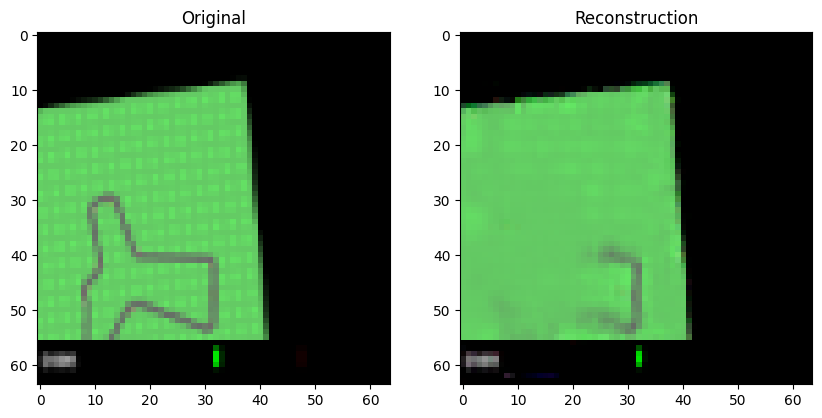

In [23]:
import matplotlib.pyplot as plt
import torch

frame = frames[0].unsqueeze(0).to(device)

with torch.no_grad():
    reconstruction, mu, log_sigma, z = W_d.V(frame)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

ax1.imshow(frames[0].permute(1, 2, 0).numpy())
ax1.set_title("Original")

ax2.imshow(reconstruction.squeeze(0).permute(1, 2, 0).cpu().numpy())
ax2.set_title("Reconstruction")

plt.show()

### Load Actions for M training

In [24]:
class ActionDataset(Dataset):
    def __init__(self, actions):
        self.actions = actions
    
    def __len__(self):
        return len(self.actions)
    
    def __getitem__(self, idx):
        return torch.tensor(self.actions[idx])
    
actions = ActionDataset(np.load("data/actions.npy"))
action_loader = DataLoader(actions, batch_size=32, shuffle=True)

In [26]:
SEQ_LEN = 32

episodes = np.load("data/episodes.npy", allow_pickle=True)

encoded_episodes = []
with torch.no_grad():
    for frames, actions in episodes:
        z_seq = []
        for frame in frames:
            frame_t = torch.FloatTensor(frame).unsqueeze(0).to(device)
            _, mu, _, _ = W_d.V(frame_t)
            z_seq.append(mu.squeeze(0))
        encoded_episodes.append((z_seq, actions))

In [27]:
class SequenceDataset(Dataset):
    def __init__(self, episodes, seq_len):
        self.sequences = []
        for z_seq, actions in episodes:
            for i in range(0, len(z_seq) - seq_len, seq_len):
                z_window = torch.stack(z_seq[i:i+seq_len])
                a_window = torch.FloatTensor(actions[i:i+seq_len])
                z_next_window = torch.stack(z_seq[i+1:i+seq_len+1])
                self.sequences.append((z_window, a_window, z_next_window))
    
    def __len__(self):
        return len(self.sequences)
    
    def __getitem__(self, idx):
        return self.sequences[idx]

seq_dataset = SequenceDataset(encoded_episodes, SEQ_LEN)
seq_loader = DataLoader(seq_dataset, batch_size=32, shuffle=True)

/var/folders/6f/xt4gfqy54470yf08dnyr5dl40000gn/T/ipykernel_56332/2613503399.py:7: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/utils/tensor_new.cpp:256.)
  a_window = torch.FloatTensor(actions[i:i+seq_len])


In [28]:
optimizer = torch.optim.Adam(W_d.M.parameters(), lr=1e-3)

def train_m(model, epochs=10):
    model.train()
    for epoch in range(epochs):
        total_loss = 0
        h = None
        for z_t, a_t, z_next in seq_loader:
            z_t = z_t.to(device)
            a_t = a_t.to(device)
            z_next = z_next.to(device)

            optimizer.zero_grad()

            mu, sigma, pi, _ = model(z_t, a_t, h)

            loss = mdn_loss(mu, sigma, pi, z_next, 5, 32)
            loss.backward()

            optimizer.step()

            total_loss += loss.item()
        
        print(f"Epoch {epoch} loss: {total_loss / len(seq_loader)}")

In [29]:
train_m(W_d.M, epochs=5)

Epoch 0 loss: -13.601483617510114
Epoch 1 loss: -42.00840696996572
Epoch 2 loss: -48.81543038815868
Epoch 3 loss: -55.44132917754504
Epoch 4 loss: -57.959114541812816


In [30]:
import cma

def get_flat_weights(model):
    return torch.cat([p.flatten() for p in model.parameters()]).detach().cpu().numpy()

def set_flat_weights(model, flat_weights):
    idx = 0
    for p in model.parameters():
        num_params = p.numel()
        
        new_weights = torch.tensor(flat_weights[idx : idx + num_params], dtype=torch.float32).reshape(p.shape)
        
        p.data.copy_(new_weights.to(device))
        idx += num_params

def evaluate_controller(flat_weights):
    set_flat_weights(W_d.C, flat_weights)
    reward = W_d.rollout() 
    return -reward

def train_c(max_gens=250):
    initial_weights = get_flat_weights(W_d.C)
    es = cma.CMAEvolutionStrategy(initial_weights, sigma0=0.1, inopts={'popsize': 16})
    
    generation = 0
    try:
        while not es.stop():
            solutions = es.ask()
            fitness_scores = [evaluate_controller(w) for w in solutions]
            es.tell(solutions, fitness_scores)
            
            best_reward = -np.min(fitness_scores)
            print(f"Generation {generation} | Best Reward: {best_reward:.2f}")
            
            if generation % 10 == 0:
                best_w = es.result.xbest
                set_flat_weights(W_d.C, best_w)
                torch.save(W_d.C.state_dict(), "controller_best.pth")
                print(f"--> Saved checkpoint at Gen {generation}")

            generation += 1
            if generation >= max_gens:
                break
                
    except KeyboardInterrupt:
        print("\nTraining interrupted by user.")
    
    print("Loading best weights found into Controller...")
    set_flat_weights(W_d.C, es.result.xbest)
    torch.save(W_d.C.state_dict(), "controller_final.pth")
    return es.result.xbest

In [31]:
checkpoint_path = "controller_best.pth"
if os.path.exists(checkpoint_path):
    W_d.C.load_state_dict(torch.load(checkpoint_path, map_location=device))
    print(f"--> Loaded {checkpoint_path}. Resuming from previous best.")
else:
    print("--> No checkpoint found. Starting from scratch.")

train_c()

--> No checkpoint found. Starting from scratch.
(8_w,16)-aCMA-ES (mu_w=4.8,w_1=32%) in dimension 867 (seed=176713, Thu Feb 26 10:46:27 2026)
Generation 0 | Best Reward: -32.48
--> Saved checkpoint at Gen 0
Generation 1 | Best Reward: -23.55
Generation 2 | Best Reward: -16.96
Generation 3 | Best Reward: -31.74
Generation 4 | Best Reward: -11.02
Generation 5 | Best Reward: -3.78
Generation 6 | Best Reward: -17.27
Generation 7 | Best Reward: 62.06
Generation 8 | Best Reward: 82.43
Generation 9 | Best Reward: 164.93
Generation 10 | Best Reward: 56.36
--> Saved checkpoint at Gen 10
Generation 11 | Best Reward: 54.08
Generation 12 | Best Reward: 77.78
Generation 13 | Best Reward: 38.78
Generation 14 | Best Reward: 44.37
Generation 15 | Best Reward: 61.40
Generation 16 | Best Reward: 64.29
Generation 17 | Best Reward: 90.63
Generation 18 | Best Reward: 46.10
Generation 19 | Best Reward: 47.80
Generation 20 | Best Reward: 100.00
--> Saved checkpoint at Gen 20
Generation 21 | Best Reward: 63.64

array([ 7.21668539e-01,  9.00657313e-02, -4.08815676e-01,  4.01770528e-02,
        5.87593964e-01, -1.04485494e-02, -3.05678504e-01,  9.92570116e-02,
        1.50352365e-01, -4.21505271e-01, -7.30099632e-01, -3.29831853e-01,
        8.86367363e-02, -3.14769281e-01,  6.94314738e-01,  1.46319900e-01,
        3.90873910e-01, -9.73650322e-02,  5.70739239e-01, -5.43177773e-02,
        3.85860183e-01,  1.48481198e+00, -2.12742444e+00,  1.12832477e-01,
       -1.19026430e+00,  5.22066198e-02, -2.67327281e-01,  5.04020492e-01,
       -1.91479905e-01, -7.38475683e-02,  4.22149813e-01, -3.30046933e-01,
        2.53738942e-01,  1.56977652e-01, -7.49184735e-02, -1.10306623e-01,
        9.07425730e-01,  5.57625200e-01,  1.13311789e+00,  1.81894174e-01,
       -4.18904891e-01,  6.83088414e-02, -5.32498877e-01, -2.70981972e-01,
       -1.99962477e-01, -1.15718904e+00, -2.75548685e-01, -7.23417802e-01,
        1.96944959e-01,  1.41948057e-01,  1.04836221e+00, -4.52631429e-01,
       -1.09870240e+00, -

In [32]:
torch.save(W_d.state_dict(), "world_model_full.pth")
print("World Model saved successfully to 'world_model_full.pth'")

loaded_world_model = WorldModel(
    d_latent=32, 
    d_hidden=256, 
    num_gaussians=5, 
    num_actions=3, 
    temperature=1, 
    environment=env
)

World Model saved successfully to 'world_model_full.pth'


In [34]:
loaded_world_model.load_state_dict(torch.load("world_model_full.pth", map_location=device, weights_only=True))
loaded_world_model.to(device)
loaded_world_model.eval()
print("World Model loaded and ready for inference!")

World Model loaded and ready for inference!


In [39]:
import gymnasium as gym
import torch

def watch_agent(world_model):
    print("Starting the engine...")
    render_env = gym.make("CarRacing-v3", render_mode="human")
    
    try:
        obs, _ = render_env.reset()
        h = (torch.zeros(1, 1, world_model.d_hidden).to(device), 
             torch.zeros(1, 1, world_model.d_hidden).to(device))
             
        done = False
        total_reward = 0

        while not done:
            frame = preprocess_frame(obs)
            obs_tensor = torch.FloatTensor(frame).unsqueeze(0).to(device)

            with torch.no_grad():
                _, _, _, z = world_model.V(obs_tensor)
                a = world_model.C(z, h[0].squeeze(0))
                action = a.squeeze(0).cpu().numpy()

                obs, reward, terminated, truncated, _ = render_env.step(action)
                done = terminated or truncated
                total_reward += reward

                _, _, _, next_h = world_model.M(z.unsqueeze(1), a.unsqueeze(1), h)
                
                h = (next_h[0].unsqueeze(0), 
                     next_h[1].unsqueeze(0))

        print(f"Agent finished the track with a score of: {total_reward:.2f}")

    except Exception as e:
        print(f"An error occurred: {e}")
        
    finally:
        print("Closing the environment window...")
        render_env.close()

watch_agent(loaded_world_model)

Starting the engine...
Agent finished the track with a score of: 396.60
Closing the environment window...
